# Predicción de Abandono Temprano en Spotify — TP Minería de Datos (UTDT)
## Vecindad de bloques: el contexto temporal alrededor de cada reproducción

Competencia Kaggle: predecir si una reproducción es "abandono temprano" (`ms_played < 30000`). Métrica: ROC-AUC.

**Segundo notebook post-clases.** Parte de la base mínima heredada de las Clases 1–5 **más el historial fino** (`u_track_veces`, `u_track_recencia` — AUC CV 0.8466, Kaggle 0.85775) y el cuerpo es la **vecindad de bloques**: hoy el modelo sabe cuánta actividad hay en el bloque de 30 minutos de la fila (`bucket_count_30min`, `pos_en_bucket`) y en el día (`bucket_count_dia`), pero no sabe nada del **paisaje alrededor**: ¿el bloque anterior también estaba cargado? ¿y el siguiente? ¿cuánta actividad hay en las 2 horas que rodean la reproducción? ¿es el primer arranque del día o el quinto? ¿cuántos bloques seguidos lleva encadenados? Una ráfaga de skips en medio de una sesión larga y un bloque aislado a la madrugada son mundos distintos que hoy comparten features.

Cuatro grupos (protocolo acumulativo de siempre — cada uno sobre lo ya adoptado, queda solo si el AUC CV sube estrictamente), todos **metadata pura** de `user_id`/`ts` — misma legitimidad batch que `bucket_count_30min` y `gap_siguiente`, ningún target involucrado:

1. **V1 — bloques contiguos**: `bucket_prev_count`, `bucket_next_count` — reproducciones del usuario en el bloque inmediatamente anterior/siguiente (0 si estuvo inactivo).
2. **V2 — ventanas móviles ±2h**: `plays_2h_antes`, `plays_2h_despues` — actividad total en los 4 bloques previos/siguientes (las "ventanas móviles" del catálogo de la Clase 3, sobre el panel usuario-tiempo).
3. **V3 — posición en el día**: `pos_en_dia` (qué número de reproducción del día es esta) y `bloque_idx_dia` (qué número de bloque activo del día es este).
4. **V4 — racha de bloques**: `racha_bloques` — cuántos bloques de 30 min consecutivos lleva activos el usuario, contando este (profundidad de la sesión en curso).

**Sin bloque de Optuna esta vez, con motivo medido:** la receta (`depth=7, eta≈0.030`) resultó robusta a cambios de features dos veces consecutivas (Clase 5 y historial: 50 trials en total, ninguno la superó). El tuneo fino queda donde la clase lo recomienda — el último paso antes de la entrega. Sí se re-testea la ventana de datos (sexta pasada) y se cierra igual que siempre: **una única mirada** a `test_interno`, submission con el 100% de train. Decisiones **solo** contra la CV temporal.

Progreso en vivo en **`logs/08_progreso_vecindad.log`** (corrida completa: ~14 min).

## Base heredada de las Clases 1–5 + historial fino (mínima)

Carga, target y derivadas de la Clase 1; validación de la Clase 2 (test interno 15% + CV de ventana expansiva de 4 folds; ventana de train 24 meses, re-validada cinco veces); numéricas de las Clases 3–4; columnas de la API de la Clase 5; historial de canción del notebook anterior (`u_track_veces`, `u_track_recencia`); receta de Optuna de la Clase 5, dos veces confirmada. Los skip-rates y el cluster de canciones quedaron rechazados con evidencia y no se heredan.

Números fijos a superar (historial fino): **AUC CV 0.8466** (se reproduce abajo), **`test_interno` 0.8432**, Kaggle público 0.85775.

In [1]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import xgboost as xgb

from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
DATA_DIR = "../competition_data"
LOG_VEC = "../logs/08_progreso_vecindad.log"

# Estilo unico (misma paleta validada de las Clases 4-5).
C_AZUL, C_AQUA, C_AMARILLO = "#2a78d6", "#1baf7a", "#eda100"
C_TEXTO, C_MUTED, C_GRILLA, C_EJES = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRILLA, "grid.linewidth": 0.8,
    "axes.edgecolor": C_EJES, "axes.labelcolor": C_TEXTO,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})

open(LOG_VEC, "w", encoding="utf-8").close()


def log_progreso(msg):
    """Mismo sistema de siempre: timestamp, print y linea appendeada al log."""
    linea = f"[{time.strftime('%H:%M:%S')}] {msg}"
    print(linea, flush=True)
    with open(LOG_VEC, "a", encoding="utf-8") as flog:
        flog.write(linea + "\n")


log_progreso(f"Vecindad de bloques -- xgboost {xgb.__version__}")

[01:58:12] Vecindad de bloques -- xgboost 3.2.0


In [2]:
USECOLS = [
    "obs_id", "ms_played", "ts", "platform_family", "conn_country",
    "master_metadata_album_artist_name",
    "spotify_track_uri", "spotify_episode_uri", "audiobook_uri",
    "shuffle", "offline", "incognito_mode", "user_id",
]
DTYPES = {
    "spotify_track_uri": "string", "spotify_episode_uri": "string", "audiobook_uri": "string",
}

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.txt", sep="\t", usecols=USECOLS, dtype=DTYPES, low_memory=False)
train_raw["target"] = (train_raw["ms_played"] < 30000).astype(int)

train_raw["content_type"] = np.select(
    [train_raw["spotify_track_uri"].notna(),
     train_raw["spotify_episode_uri"].notna(),
     train_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
ts_dt = pd.to_datetime(train_raw["ts"], utc=True, format="ISO8601")
train_raw["ts_dt"] = ts_dt
train_raw["hora"] = ts_dt.dt.hour
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
train_raw["dia_semana"] = ts_dt.dt.dayofweek.map(dict(enumerate(DIAS)))

col_artista = "master_metadata_album_artist_name"
TOP_ARTISTAS = train_raw[col_artista].value_counts().head(50).index
train_raw["artista_top"] = train_raw[col_artista].where(train_raw[col_artista].isin(TOP_ARTISTAS), "otros")

train_raw = train_raw.sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)
log_progreso(f"train cargado: {len(train_raw):,} filas | tasa de abandono {train_raw['target'].mean():.4f}")

[01:58:17] train cargado: 911,344 filas | tasa de abandono 0.2780


In [3]:
n = len(train_raw)
n_train = int(n * 0.85)
df_train = train_raw.iloc[:n_train].copy()
df_test_interno = train_raw.iloc[n_train:].copy()

for nombre, df in [("train", df_train), ("test interno", df_test_interno)]:
    print(f"{nombre:<13} {len(df):>7,} filas | {df['ts_dt'].min().date()} -> {df['ts_dt'].max().date()} "
          f"| tasa abandono {df['target'].mean():.4f}")

train         774,642 filas | 2013-10-29 -> 2023-05-26 | tasa abandono 0.2865
test interno  136,702 filas | 2023-05-26 -> 2024-08-31 | tasa abandono 0.2298


In [4]:
# Numericas heredadas (Clases 3-4), sobre train+test_interno concatenados.
full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])

gap = full.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
full["gap_min"] = gap.fillna(-1)
full["bucket_count_30min"] = full.groupby(["user_id", "ts"])["obs_id"].transform("size")
full["pos_en_bucket"] = full.groupby(["user_id", "ts"]).cumcount()
fecha = full["ts_dt"].dt.floor("D")
full["bucket_count_dia"] = full.groupby(["user_id", fecha])["obs_id"].transform("size")
gap_sig = (full.groupby("user_id")["ts_dt"].shift(-1) - full["ts_dt"]).dt.total_seconds() / 60.0
full["gap_siguiente"] = gap_sig.fillna(-1)

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]
log_progreso("numericas heredadas listas (Clases 3-4)")

[01:58:20] numericas heredadas listas (Clases 3-4)


In [5]:
# Columnas de la API (Clase 5) + historial de cancion (notebook anterior), heredadas.
api = pd.read_pickle(f"{DATA_DIR}/api_features.pkl")
api_idx = api.set_index("uri")


def agregar_columnas_api(df):
    """Mapea la metadata de la API por URI y construye las derivadas adoptadas en la Clase 5.
    Requiere ts_dt y bucket_count_30min ya calculados."""
    df["uri"] = df["spotify_track_uri"].fillna(df["spotify_episode_uri"])
    df["duracion_ms"] = df["uri"].map(api_idx["duration_ms"])
    df["popularity"] = df["uri"].map(api_idx["popularity"])
    df["explicit_num"] = df["uri"].map(api_idx["explicit"].astype(float))
    df["track_number"] = df["uri"].map(api_idx["track_number"])
    df["album_total_tracks"] = df["uri"].map(api_idx["album_total_tracks"])

    rel = df["uri"].map(api_idx["release_date"]).astype("string")
    rel = rel.where(rel.str.len() != 4, rel + "-01-01")
    rel = rel.where(rel.str.len() != 7, rel + "-01")
    release_dt = pd.to_datetime(rel, errors="coerce", utc=True)
    df["antiguedad_dias"] = (df["ts_dt"] - release_dt).dt.days.astype(float)

    dur = df["duracion_ms"]
    df["dur_menor_30s"] = np.where(dur.isna(), np.nan, (dur < 30000).astype(float))
    df["carga_bucket"] = df["bucket_count_30min"] * dur / (30 * 60 * 1000)
    return df


full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])
full = agregar_columnas_api(full)

# Historial de cancion (H1 del notebook anterior): expanding estricto por (user, uri).
full["uri_key"] = full["uri"].fillna("sin_uri")
gt = full.groupby(["user_id", "uri_key"], sort=False)
full["u_track_veces"] = gt.cumcount()
full["u_track_recencia"] = (gt["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]
log_progreso(f"API + historial de cancion listos | cobertura API {full['duracion_ms'].notna().mean():.1%}")

[01:58:25] API + historial de cancion listos | cobertura API 99.9%


In [6]:
TODAS_LAS_FEATURES = ["platform_family", "conn_country", "shuffle", "offline", "incognito_mode",
                      "hora", "dia_semana", "content_type", "artista_top"]
CAT_FINAL = [f for f in TODAS_LAS_FEATURES if f != "hora"] + ["user_id"]
NUM_FINAL = ["gap_min", "bucket_count_30min", "pos_en_bucket", "bucket_count_dia", "gap_siguiente", "hora",
             "duracion_ms", "dur_menor_30s", "carga_bucket", "popularity", "antiguedad_dias",
             "explicit_num", "track_number", "album_total_tracks",
             "u_track_veces", "u_track_recencia"]

# Receta de Optuna de la Clase 5 (trial 26), confirmada dos veces, floats exactos.
RECETA = dict(max_depth=7, eta=0.030223664895420776, min_child_weight=2,
              subsample=0.7963585977878456, colsample_bytree=0.79208902443077,
              gamma=0.8414960952850874)
BASE_PARAMS_XGB = dict(objective="binary:logistic", eval_metric="auc", seed=RANDOM_STATE)
NUM_BOOST_MAX, EARLY_STOP, N_FOLDS = 600, 25, 4
VENTANA_HEREDADA = 24

AUC_HIST_CV, AUC_HIST_TEST, SCORE_HIST_KAGGLE = 0.8466, 0.8432, 0.85775


def filtrar_reciente(df, meses):
    if meses is None:
        return df
    corte = df["ts_dt"].max() - pd.DateOffset(months=int(meses))
    return df[df["ts_dt"] >= corte]


def make_expanding_folds(df, n_folds=4):
    n = len(df)
    bordes = np.linspace(0, n, n_folds + 2, dtype=int)
    folds = []
    for i in range(1, n_folds + 1):
        idx_train = np.arange(0, bordes[i])
        idx_val = np.arange(bordes[i], bordes[i + 1])
        if len(idx_val) > 0 and len(idx_train) > 0:
            folds.append((idx_train, idx_val))
    return folds


def limpiar_nombres_columnas(cols):
    limpios = [re.sub(r"[\[\]<]", "_", str(c)) for c in cols]
    vistos, out = {}, []
    for c in limpios:
        if c in vistos:
            vistos[c] += 1
            out.append(f"{c}__dup{vistos[c]}")
        else:
            vistos[c] = 0
            out.append(c)
    return out


def build_sparse_matrix(df, cat_features, num_features):
    cat_features = list(cat_features)
    cat_dummies = pd.get_dummies(df[cat_features], columns=cat_features, dummy_na=True, sparse=True)
    X_cat = sp.csr_matrix(cat_dummies.sparse.to_coo())
    X_num = sp.csr_matrix(df[list(num_features)].astype(float).values)
    X = sp.hstack([X_cat, X_num], format="csr")
    feature_names = limpiar_nombres_columnas(list(cat_dummies.columns.astype(str)) + list(num_features))
    y = df["target"].to_numpy()
    return X, y, feature_names


def evaluar_cv(cat_feats, num_feats, params, ventana=VENTANA_HEREDADA, etiqueta="", df=None):
    """CV temporal de siempre (4 folds expansivos, train filtrado a la ventana).
    df=None se resuelve adentro (gotcha de las Clases 4-5)."""
    if df is None:
        df = df_train
    t0 = time.time()
    X, y, nombres = build_sparse_matrix(df, cat_feats, num_feats)
    aucs, rondas = [], []
    for idx_tr, idx_val in make_expanding_folds(df, n_folds=N_FOLDS):
        if ventana is not None:
            corte = df["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=int(ventana))
            idx_tr = idx_tr[(df["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
        dtr = xgb.DMatrix(X[idx_tr], label=y[idx_tr], feature_names=nombres)
        dva = xgb.DMatrix(X[idx_val], label=y[idx_val], feature_names=nombres)
        bst = xgb.train({**BASE_PARAMS_XGB, **params}, dtr, num_boost_round=NUM_BOOST_MAX,
                        evals=[(dva, "val")], early_stopping_rounds=EARLY_STOP, verbose_eval=False)
        aucs.append(float(bst.best_score))
        rondas.append(bst.best_iteration + 1)
    auc = float(np.mean(aucs))
    if etiqueta:
        detalle = " ".join(f"{a:.4f}" for a in aucs)
        aviso = " | OJO: cerca del tope de rondas" if np.mean(rondas) >= 580 else ""
        log_progreso(f"{etiqueta:<48s} -> AUC CV {auc:.4f} | folds [{detalle}] | rondas prom {np.mean(rondas):3.0f} | {time.time() - t0:4.0f}s{aviso}")
    return auc, aucs, float(np.mean(rondas)), X.shape[1]


print(f"CAT_FINAL ({len(CAT_FINAL)}) | NUM_FINAL ({len(NUM_FINAL)})")
print(f"A superar -- AUC CV: {AUC_HIST_CV:.4f} | test_interno: {AUC_HIST_TEST:.4f} | Kaggle: {SCORE_HIST_KAGGLE}")

CAT_FINAL (9) | NUM_FINAL (16)
A superar -- AUC CV: 0.8466 | test_interno: 0.8432 | Kaggle: 0.85775


### Sanidad: reproducir la referencia del historial fino antes de tocar nada

Si esta corrida no reproduce el **0.8466** (mismo feature set, misma receta, misma semilla), nada de lo que sigue es comparable.

In [7]:
log_progreso("=== Sanidad: reproducir la referencia del historial fino ===")
AUC_REF, _, RONDAS_REF, COLS_REF = evaluar_cv(CAT_FINAL, NUM_FINAL, RECETA,
                                              etiqueta="referencia heredada (esperado 0.8466)")
if abs(AUC_REF - AUC_HIST_CV) > 0.0005:
    log_progreso(f"ATENCION: la referencia ({AUC_REF:.4f}) no reproduce el {AUC_HIST_CV:.4f} esperado")
else:
    log_progreso(f"sanidad OK: referencia {AUC_REF:.4f} ({COLS_REF} columnas)")

[01:58:25] === Sanidad: reproducir la referencia del historial fino ===
[01:59:55] referencia heredada (esperado 0.8466)            -> AUC CV 0.8466 | folds [0.7939 0.8454 0.8960 0.8510] | rondas prom 358 |   91s
[01:59:55] sanidad OK: referencia 0.8466 (151 columnas)


## Cuerpo: las features de vecindad

Construcción, toda a nivel **bloque** (la grilla de 30 minutos que define `ts`): una tabla de bloques activos por usuario (`(user_id, ts_dt)` únicos, con su conteo de reproducciones) y lookups vectorizados con offsets de ±30 min. Sobre esa tabla:

- `bucket_prev_count` / `bucket_next_count`: el conteo del bloque a −30/+30 min del actual (0 si el usuario no tuvo actividad ahí).
- `plays_2h_antes` / `plays_2h_despues`: suma de los conteos de los 4 bloques anteriores/siguientes (2 horas hacia cada lado).
- `pos_en_dia`: cumcount de la reproducción dentro del día del usuario (el análogo diario de `pos_en_bucket`).
- `bloque_idx_dia`: índice del bloque actual entre los bloques activos del usuario ese día (0 = el arranque del día).
- `racha_bloques`: largo de la cadena de bloques consecutivos (pasos de exactamente 30 min) que termina en el bloque actual — la "profundidad de sesión". Complementa a `gap_min`: el gap dice cuánto hace que empezó el silencio anterior; la racha dice cuánto lleva *sin* silencios.

**Disciplina temporal, heredada del precedente de `gap_siguiente` (Clase 4):** dentro del dataset etiquetado (train + test interno) todo se calcula sobre el concatenado — es metadata batch, disponible completa en el archivo. En el test real de Kaggle: lo que mira **hacia atrás** (prev, 2h antes, posición en el día, racha) se calcula con continuidad train→test (el 1° de septiembre a las 00:00, el bloque anterior es el último de agosto — y la racha puede venir encadenada desde train); lo que mira **hacia adelante** (next, 2h después) se calcula autocontenido dentro de cada conjunto, sin que las filas de train vean bloques del test.

In [8]:
def agregar_vecindad(df):
    """Features de vecindad de bloques sobre un frame cronologicamente ordenado.
    Todas derivadas de (user_id, ts_dt): conteos de bloques vecinos, ventanas +-2h,
    posicion en el dia y racha de bloques consecutivos."""
    cnt_bloque = df.groupby(["user_id", "ts_dt"]).size()

    def conteo_offset(k_bloques):
        idx = pd.MultiIndex.from_arrays([df["user_id"], df["ts_dt"] + pd.Timedelta(minutes=30 * k_bloques)])
        return cnt_bloque.reindex(idx).fillna(0).to_numpy()

    df["bucket_prev_count"] = conteo_offset(-1)
    df["bucket_next_count"] = conteo_offset(+1)
    df["plays_2h_antes"] = sum(conteo_offset(-k) for k in (1, 2, 3, 4))
    df["plays_2h_despues"] = sum(conteo_offset(+k) for k in (1, 2, 3, 4))

    fecha = df["ts_dt"].dt.floor("D")
    df["pos_en_dia"] = df.groupby(["user_id", fecha]).cumcount()

    # tabla de bloques activos por usuario (ordenada) para indice diario y racha
    bloques = df[["user_id", "ts_dt"]].drop_duplicates().sort_values(["user_id", "ts_dt"])
    fecha_b = bloques["ts_dt"].dt.floor("D")
    bloques["bloque_idx_dia"] = bloques.groupby(["user_id", fecha_b]).cumcount()
    paso = bloques.groupby("user_id")["ts_dt"].diff()
    nueva_racha = (paso != pd.Timedelta(minutes=30)) | paso.isna()
    racha_id = nueva_racha.groupby(bloques["user_id"]).cumsum()
    bloques["racha_bloques"] = bloques.groupby([bloques["user_id"], racha_id]).cumcount() + 1

    tabla = bloques.set_index(["user_id", "ts_dt"])
    idx_filas = pd.MultiIndex.from_arrays([df["user_id"], df["ts_dt"]])
    df["bloque_idx_dia"] = tabla["bloque_idx_dia"].reindex(idx_filas).to_numpy()
    df["racha_bloques"] = tabla["racha_bloques"].reindex(idx_filas).to_numpy()
    return df


full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])
full = agregar_vecindad(full)
df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]

COLS_VECINDAD = ["bucket_prev_count", "bucket_next_count", "plays_2h_antes", "plays_2h_despues",
                 "pos_en_dia", "bloque_idx_dia", "racha_bloques"]
log_progreso("features de vecindad listas | bloque previo activo en "
             f"{(df_train['bucket_prev_count'] > 0).mean():.1%} de las filas | racha mediana "
             f"{df_train['racha_bloques'].median():.0f} bloques")
print(df_train[COLS_VECINDAD].describe().round(1).to_string())

[02:00:02] features de vecindad listas | bloque previo activo en 70.8% de las filas | racha mediana 2 bloques
       bucket_prev_count  bucket_next_count  plays_2h_antes  plays_2h_despues  pos_en_dia  bloque_idx_dia  racha_bloques
count           774642.0           774642.0        774642.0          774642.0    774642.0        774642.0       774642.0
mean                 7.6                7.6            17.8              17.8        48.3             4.6            3.1
std                 13.2               13.9            25.0              25.7        55.0             4.4            2.6
min                  0.0                0.0             0.0               0.0         0.0             0.0            1.0
25%                  0.0                0.0             1.0               1.0        13.0             1.0            1.0
50%                  6.0                6.0            10.0              10.0        31.0             3.0            2.0
75%                 10.0               10.0

In [9]:
GRUPOS_V = [
    ("V1 bloques contiguos",   ["bucket_prev_count", "bucket_next_count"]),
    ("V2 ventanas +-2h",       ["plays_2h_antes", "plays_2h_despues"]),
    ("V3 posicion en el dia",  ["pos_en_dia", "bloque_idx_dia"]),
    ("V4 racha de bloques",    ["racha_bloques"]),
]

log_progreso(f"=== Vecindad de bloques (acumulativo, referencia {AUC_REF:.4f}) ===")
num_actual = list(NUM_FINAL)
auc_actual, rondas_actual = AUC_REF, RONDAS_REF
historial_V = []
for etiqueta, cols in GRUPOS_V:
    auc, _, rondas, _ = evaluar_cv(CAT_FINAL, num_actual + cols, RECETA, etiqueta=f"+ {etiqueta}")
    adoptado = auc > auc_actual
    historial_V.append({"grupo": etiqueta, "auc_cv": round(auc, 4),
                        "delta": round(auc - auc_actual, 4), "adoptado": adoptado})
    log_progreso(f"    {'ADOPTADO' if adoptado else 'rechazado'}: {etiqueta} ({auc - auc_actual:+.4f})")
    if adoptado:
        num_actual = num_actual + cols
        auc_actual, rondas_actual = auc, rondas

NUM_VEC = num_actual
AUC_REF_V = auc_actual
ADOPTADAS_V = [c for c in NUM_VEC if c not in NUM_FINAL]

print("\nResumen (cada delta es contra la referencia acumulada al momento de probar):")
print(pd.DataFrame(historial_V).to_string(index=False))
log_progreso(f"cierre vecindad: AUC CV {AUC_REF_V:.4f} ({AUC_REF_V - AUC_REF:+.4f} vs. herencia) | adoptadas: {ADOPTADAS_V}")

[02:00:03] === Vecindad de bloques (acumulativo, referencia 0.8466) ===
[02:01:26] + V1 bloques contiguos                           -> AUC CV 0.8576 | folds [0.8068 0.8565 0.9048 0.8624] | rondas prom 318 |   84s
[02:01:27]     ADOPTADO: V1 bloques contiguos (+0.0110)
[02:02:49] + V2 ventanas +-2h                               -> AUC CV 0.8578 | folds [0.8064 0.8569 0.9050 0.8627] | rondas prom 318 |   82s
[02:02:49]     ADOPTADO: V2 ventanas +-2h (+0.0001)
[02:04:06] + V3 posicion en el dia                          -> AUC CV 0.8574 | folds [0.8053 0.8571 0.9049 0.8621] | rondas prom 286 |   77s
[02:04:06]     rechazado: V3 posicion en el dia (-0.0004)
[02:05:46] + V4 racha de bloques                            -> AUC CV 0.8577 | folds [0.8066 0.8569 0.9050 0.8623] | rondas prom 333 |  101s
[02:05:46]     rechazado: V4 racha de bloques (-0.0000)

Resumen (cada delta es contra la referencia acumulada al momento de probar):
                grupo  auc_cv   delta  adoptado
 V1 bloques cont

**Resultado: AUC CV 0.8466 → 0.8578 (+0.0112) — el salto de features más grande desde `bucket_count_30min` en la Clase 3.**

| Grupo | AUC CV | Δ | Veredicto |
|---|---|---|---|
| **V1 — bloques contiguos** (`bucket_prev_count`, `bucket_next_count`) | 0.8576 | **+0.0110** | **adoptado** |
| V2 — ventanas ±2h (`plays_2h_antes`, `plays_2h_despues`) | 0.8578 | +0.0001 | adoptado (marginal) |
| V3 — posición en el día (`pos_en_dia`, `bloque_idx_dia`) | 0.8574 | −0.0004 | rechazado |
| V4 — racha de bloques (`racha_bloques`) | 0.8577 | −0.0000 | rechazado |

- **Casi todo el salto es V1, y mejora los 4 folds con fuerza** (el más viejo, siempre el más difícil, sube +0.013 hasta 0.807). La lectura mecánica es preciosa: `bucket_count_30min` ya decía "este bloque está cargado ⇒ hubo cortes"; los vecinos dicen si esa carga es una **sesión de zapping sostenida** (bloques contiguos también llenos) o un **pico aislado** — contexto que ninguna feature anterior veía. `bucket_prev_count` entró al top-15 de importancias del modelo.
- **V2 se adopta pero al borde del ruido** (+0.0001): las ventanas de ±2h agregan poquísimo sobre los bloques inmediatos ya presentes — el vecino contiguo captura casi todo el contexto útil, y estirar a 2 horas apenas suma. La regla acumulativa pre-comprometida (mejora estricta) la deja entrar, y `plays_2h_antes` sí aparece en el top-15, pero es honesto llamarlo lo que es: una mejora marginal, no un segundo hallazgo. En un consolidado final orientado a la simplicidad sería defendible dejarla afuera.
- **V3 y V4 rechazados por solapamiento, no por falta de señal**: la posición en el día y la profundidad de sesión son información *real*, pero ya está implícita en la combinación de `pos_en_bucket`, `bucket_count_dia` y los conteos de vecinos — el protocolo acumulativo hace visible que no agregan nada nuevo una vez que V1 está adentro. Es exactamente el tipo de redundancia que el orden de evaluación está para detectar (mismo patrón que H2-artista en el notebook anterior).

### Ventana de datos, sexta pasada (y por qué sin Optuna)

La ventana se re-testea porque es barata (4 evaluaciones) y porque cada cambio de feature set puede moverla — ya pasó que estuvo cerca de moverse con el historial. El re-tuneo de hiperparámetros, en cambio, se saltea **con evidencia**: 50 trials de Optuna en los dos notebooks anteriores no encontraron nada mejor que la receta vigente, y la recomendación explícita de la clase es dejar el tuneo fino para el final del proyecto. Si la vecindad cambia el paisaje de forma dramática (no es lo esperable con conteos de la misma familia), el cierre pre-entrega lo va a detectar. Sanidad: la fila de 24 meses debe reproducir el cierre de la vecindad.

In [10]:
log_progreso("=== Re-test de ventana (feature set final) ===")
resultados_v = []
for ventana in [12, 24, 36, None]:
    etiqueta = "toda la historia" if ventana is None else f"{ventana} meses"
    auc, _, rondas, _ = evaluar_cv(CAT_FINAL, NUM_VEC, RECETA, ventana=ventana,
                                   etiqueta=f"ventana {etiqueta}")
    resultados_v.append({"ventana": etiqueta, "meses": ventana, "auc_cv": auc, "rondas": rondas})

res_v = pd.DataFrame(resultados_v).sort_values("auc_cv", ascending=False).reset_index(drop=True)
print("\n" + res_v[["ventana", "auc_cv"]].round(4).to_string(index=False))

VENTANA_V = res_v.loc[0, "meses"]
VENTANA_V = None if pd.isna(VENTANA_V) else int(VENTANA_V)
AUC_CIERRE_CV = float(res_v.loc[0, "auc_cv"])
NROUNDS_V = int(round(float(res_v.loc[0, "rondas"])))

fila_24 = res_v[res_v["meses"] == 24]["auc_cv"].iloc[0]
log_progreso(f"sanidad: 24 meses reproduce el cierre de la vecindad? {fila_24:.4f} vs. {AUC_REF_V:.4f}")
etiqueta_vv = "toda la historia" if VENTANA_V is None else f"{VENTANA_V} meses"
log_progreso(f"decision de ventana: {etiqueta_vv} -> AUC CV de cierre {AUC_CIERRE_CV:.4f} | NROUNDS_V={NROUNDS_V}")

[02:05:46] === Re-test de ventana (feature set final) ===
[02:06:53] ventana 12 meses                                 -> AUC CV 0.8558 | folds [0.8075 0.8549 0.9029 0.8579] | rondas prom 253 |   66s
[02:08:18] ventana 24 meses                                 -> AUC CV 0.8578 | folds [0.8064 0.8569 0.9050 0.8627] | rondas prom 318 |   85s
[02:09:33] ventana 36 meses                                 -> AUC CV 0.8572 | folds [0.8054 0.8567 0.9028 0.8639] | rondas prom 331 |   75s
[02:11:15] ventana toda la historia                         -> AUC CV 0.8574 | folds [0.8065 0.8556 0.9044 0.8630] | rondas prom 382 |  102s

         ventana  auc_cv
        24 meses  0.8578
toda la historia  0.8574
        36 meses  0.8572
        12 meses  0.8558
[02:11:16] sanidad: 24 meses reproduce el cierre de la vecindad? 0.8578 vs. 0.8578
[02:11:16] decision de ventana: 24 meses -> AUC CV de cierre 0.8578 | NROUNDS_V=318


### Comparación final honesta en `test_interno` (única mirada)

Protocolo de siempre: rondas fijadas por la CV (`NROUNDS_V`), sin early stopping contra `test_interno`, watchlist pasivo, matriz sobre la unión partida por posición. Las features de vecindad de `test_interno` ya vienen calculadas del concatenado (metadata batch — dentro del dataset etiquetado no hay frontera que respetar). La vara: **0.8432** del historial fino.

In [11]:
df_tr_final = filtrar_reciente(df_train, VENTANA_V)
df_ambos = pd.concat([df_tr_final, df_test_interno])

X_ambos, y_ambos, names_ambos = build_sparse_matrix(df_ambos, CAT_FINAL, NUM_VEC)
n_tr = len(df_tr_final)
dtr_final = xgb.DMatrix(X_ambos[:n_tr], label=y_ambos[:n_tr], feature_names=names_ambos)
dte_final = xgb.DMatrix(X_ambos[n_tr:], label=y_ambos[n_tr:], feature_names=names_ambos)

booster_final = xgb.train(
    {**BASE_PARAMS_XGB, **RECETA}, dtr_final,
    num_boost_round=NROUNDS_V,
    evals=[(dtr_final, "train"), (dte_final, "test_interno")],
    verbose_eval=50,
)

pred_test = booster_final.predict(dte_final)
auc_test_v = roc_auc_score(y_ambos[n_tr:], pred_test)

print(f"\nRondas fijadas por la CV (NROUNDS_V): {NROUNDS_V}")
print(f"AUC test_interno -- historial fino: {AUC_HIST_TEST:.4f}")
print(f"AUC test_interno -- vecindad:       {auc_test_v:.4f}")
print(f"Mejora:                             {auc_test_v - AUC_HIST_TEST:+.4f}")
log_progreso(f"TEST_INTERNO (unica mirada): vecindad {auc_test_v:.4f} vs. historial {AUC_HIST_TEST:.4f} "
             f"({auc_test_v - AUC_HIST_TEST:+.4f})")

[0]	train-auc:0.85051	test_interno-auc:0.82203
[50]	train-auc:0.87064	test_interno-auc:0.84635
[100]	train-auc:0.87807	test_interno-auc:0.85177
[150]	train-auc:0.88329	test_interno-auc:0.85400
[200]	train-auc:0.88681	test_interno-auc:0.85531
[250]	train-auc:0.88997	test_interno-auc:0.85594
[300]	train-auc:0.89283	test_interno-auc:0.85634
[317]	train-auc:0.89366	test_interno-auc:0.85649

Rondas fijadas por la CV (NROUNDS_V): 318
AUC test_interno -- historial fino: 0.8432
AUC test_interno -- vecindad:       0.8565
Mejora:                             +0.0133
[02:11:40] TEST_INTERNO (unica mirada): vecindad 0.8565 vs. historial 0.8432 (+0.0133)


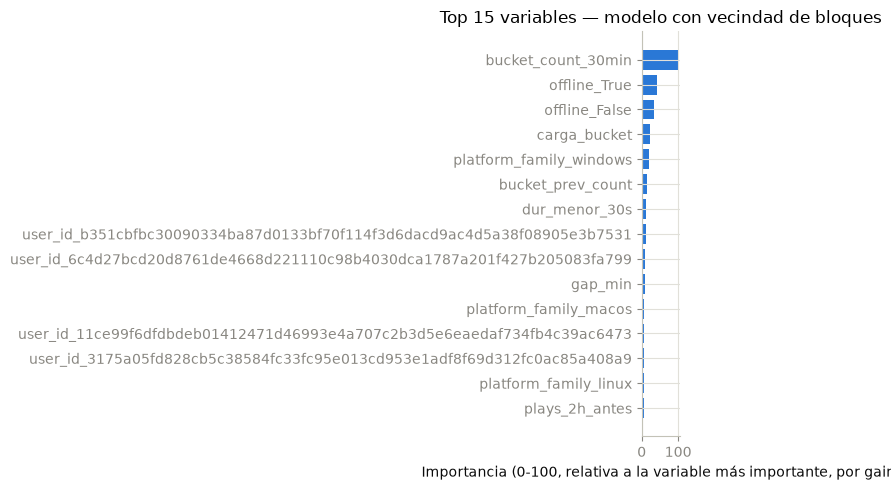

Variables usadas: 103 de 142 columnas
Features de vecindad dentro del top 15: ['bucket_prev_count', 'plays_2h_antes']


In [12]:
importancias = booster_final.get_score(importance_type="gain")
imp_df = pd.DataFrame(list(importancias.items()), columns=["feature", "gain"]).sort_values("gain", ascending=False)
imp_df["gain_norm"] = 100 * imp_df["gain"] / imp_df["gain"].max()

top_n = 15
top_imp = imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(7, 5))
plt.barh(top_imp["feature"], top_imp["gain_norm"], color=C_AZUL)
plt.xlabel("Importancia (0-100, relativa a la variable más importante, por gain)")
plt.title(f"Top {top_n} variables — modelo con vecindad de bloques")
plt.tight_layout()
plt.show()

nuevas = [f for f in imp_df["feature"].head(top_n) if f in COLS_VECINDAD]
print(f"Variables usadas: {len(imp_df)} de {len(names_ambos)} columnas")
print(f"Features de vecindad dentro del top {top_n}: {nuevas}")

### Modelo final: reentrenar con el 100% de los datos y submission

Detalles de correctitud — los heredados (gap_min con continuidad; conteos, `gap_siguiente` y el historial de canción como en el notebook anterior; API por URI) más la disciplina nueva de la vecindad:

- **Hacia atrás con continuidad**: `bucket_prev_count`, `plays_2h_antes`, `pos_en_dia`, `bloque_idx_dia` y `racha_bloques` se calculan sobre el concatenado train+test — el bloque anterior al primer bloque del test es el último de train, y una racha puede venir encadenada desde agosto. Es metadata (`ts`/conteos), disponible completa en el archivo batch.
- **Hacia adelante autocontenido**: `bucket_next_count` y `plays_2h_despues` para las filas de train se calculan solo dentro de train (como quedaron de la celda del cuerpo, donde el "futuro" visible era el propio dataset etiquetado), y para las filas de test solo dentro de test — las filas de train del modelo final nunca ven bloques del test real, el mismo criterio conservador de `gap_siguiente`.

In [13]:
train_completo = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)

test_raw = pd.read_csv(
    f"{DATA_DIR}/test_data.txt", sep="\t",
    usecols=[c for c in USECOLS if c != "ms_played"], dtype=DTYPES, low_memory=False,
)
test_raw["content_type"] = np.select(
    [test_raw["spotify_track_uri"].notna(),
     test_raw["spotify_episode_uri"].notna(),
     test_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
test_raw["ts_dt"] = pd.to_datetime(test_raw["ts"], utc=True, format="ISO8601")
test_raw["hora"] = test_raw["ts_dt"].dt.hour
test_raw["dia_semana"] = test_raw["ts_dt"].dt.dayofweek.map(dict(enumerate(DIAS)))
test_raw["artista_top"] = test_raw[col_artista].where(test_raw[col_artista].isin(TOP_ARTISTAS), "otros")

# gap_min con continuidad real train->test
combinado = pd.concat([
    train_completo[["obs_id", "user_id", "ts_dt"]],
    test_raw[["obs_id", "user_id", "ts_dt"]],
]).sort_values(["ts_dt", "obs_id"])
combinado["gap_min"] = combinado.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
test_raw["gap_min"] = test_raw["obs_id"].map(combinado.set_index("obs_id")["gap_min"]).fillna(-1)

# conteos autocontenidos en test
test_raw["bucket_count_30min"] = test_raw.groupby(["user_id", "ts"])["obs_id"].transform("size")
test_raw["pos_en_bucket"] = test_raw.groupby(["user_id", "ts"]).cumcount()
fecha_test = test_raw["ts_dt"].dt.floor("D")
test_raw["bucket_count_dia"] = test_raw.groupby(["user_id", fecha_test])["obs_id"].transform("size")
gap_sig_test = (test_raw.groupby("user_id")["ts_dt"].shift(-1) - test_raw["ts_dt"]).dt.total_seconds() / 60.0
test_raw["gap_siguiente"] = gap_sig_test.fillna(-1)

# API + historial de cancion con continuidad train->test (expanding cronologico sobre la union)
test_raw = agregar_columnas_api(test_raw)
test_raw["uri_key"] = test_raw["uri"].fillna("sin_uri")
cols_h = ["obs_id", "user_id", "ts_dt", "uri_key"]
comb_h = pd.concat([train_completo[cols_h], test_raw[cols_h]]).sort_values(["ts_dt", "obs_id"])
gt = comb_h.groupby(["user_id", "uri_key"], sort=False)
comb_h["u_track_veces"] = gt.cumcount()
comb_h["u_track_recencia"] = (gt["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)
comb_h = comb_h.set_index("obs_id")
test_raw["u_track_veces"] = test_raw["obs_id"].map(comb_h["u_track_veces"])
test_raw["u_track_recencia"] = test_raw["obs_id"].map(comb_h["u_track_recencia"])

# Vecindad HACIA ATRAS con continuidad: sobre la union train+test; las filas de train
# no cambian (el futuro no afecta lookups hacia atras) -- solo se mapea al test.
cols_v = ["obs_id", "user_id", "ts_dt"]
comb_v = pd.concat([train_completo[cols_v], test_raw[cols_v]]).sort_values(["ts_dt", "obs_id"])
comb_v = agregar_vecindad(comb_v)
comb_v = comb_v.set_index("obs_id")
for c in ["bucket_prev_count", "plays_2h_antes", "pos_en_dia", "bloque_idx_dia", "racha_bloques"]:
    test_raw[c] = test_raw["obs_id"].map(comb_v[c])

# Vecindad HACIA ADELANTE autocontenida en test (criterio gap_siguiente)
test_solo = test_raw[cols_v].sort_values(["ts_dt", "obs_id"]).copy()
test_solo = agregar_vecindad(test_solo)
test_solo = test_solo.set_index("obs_id")
for c in ["bucket_next_count", "plays_2h_despues"]:
    test_raw[c] = test_raw["obs_id"].map(test_solo[c])

log_progreso(f"test de Kaggle preparado: {len(test_raw):,} filas | bloque previo activo en "
             f"{(test_raw['bucket_prev_count'] > 0).mean():.1%} de las filas")

df_ambos_kaggle = pd.concat([filtrar_reciente(train_completo, VENTANA_V), test_raw])
n_tr_k = len(df_ambos_kaggle) - len(test_raw)
X_ak, y_ak, names_ak = build_sparse_matrix(df_ambos_kaggle, CAT_FINAL, NUM_VEC)

dtrain_kaggle = xgb.DMatrix(X_ak[:n_tr_k], label=y_ak[:n_tr_k], feature_names=names_ak)
dtest_kaggle = xgb.DMatrix(X_ak[n_tr_k:], feature_names=names_ak)

modelo_final = xgb.train({**BASE_PARAMS_XGB, **RECETA}, dtrain_kaggle, num_boost_round=NROUNDS_V)
test_pred = modelo_final.predict(dtest_kaggle)

submission = pd.DataFrame({"obs_id": test_raw["obs_id"], "target": test_pred})
submission.to_csv("../submissions/08_submission_vecindad_bloques.csv", index=False)
print(f"Guardado 08_submission_vecindad_bloques.csv -- {len(submission)} filas | "
      f"probs en [{test_pred.min():.4f}, {test_pred.max():.4f}], media {test_pred.mean():.4f}")

etiqueta_vv = "toda la historia" if VENTANA_V is None else f"{VENTANA_V} meses"
log_progreso(f"submission guardada: 08_submission_vecindad_bloques.csv ({len(submission)} filas, "
             f"{NROUNDS_V} rondas, train {n_tr_k:,} filas a {etiqueta_vv})")
log_progreso(f"RESUMEN FINAL vecindad: AUC CV {AUC_CIERRE_CV:.4f} (historial: {AUC_HIST_CV:.4f}, {AUC_CIERRE_CV - AUC_HIST_CV:+.4f}) | "
             f"test_interno {auc_test_v:.4f} (historial: {AUC_HIST_TEST:.4f}, {auc_test_v - AUC_HIST_TEST:+.4f}) | "
             f"adoptadas {ADOPTADAS_V} | ventana {etiqueta_vv}")
submission.head()

[02:11:46] test de Kaggle preparado: 51,570 filas | bloque previo activo en 73.8% de las filas
Guardado 08_submission_vecindad_bloques.csv -- 51570 filas | probs en [0.0046, 0.9952], media 0.2557
[02:11:54] submission guardada: 08_submission_vecindad_bloques.csv (51570 filas, 318 rondas, train 218,339 filas a 24 meses)
[02:11:54] RESUMEN FINAL vecindad: AUC CV 0.8578 (historial: 0.8466, +0.0112) | test_interno 0.8565 (historial: 0.8432, +0.0133) | adoptadas ['bucket_prev_count', 'bucket_next_count', 'plays_2h_antes', 'plays_2h_despues'] | ventana 24 meses


,obs_id,target
0,911345,0.200117
1,911346,0.153445
2,911347,0.108526
3,911348,0.057003
4,911349,0.054205


### Notas honestas para el informe — vecindad de bloques (con los números de la corrida ejecutada)

- **Qué se agregó:** el contexto temporal alrededor de cada reproducción — bloques contiguos (±30 min), ventanas móviles ±2h, posición en el día y racha de bloques consecutivos. Metadata pura de `user_id`/`ts`, misma familia y legitimidad batch que `bucket_count_30min`. Corrida completa ~14 min (`logs/08_progreso_vecindad.log`); sanidad inicial reprodujo el 0.8466 del historial exacto.
- **Adoptado: V1 (bloques contiguos) → +0.0110**, el salto de una sola feature más grande desde la Clase 3, mejorando los 4 folds. V2 (ventanas ±2h) se adopta al borde del ruido (+0.0001) — marginal, defendible dejarla afuera en un consolidado orientado a simplicidad. Rechazados con evidencia: V3 posición en el día (−0.0004) y V4 racha (−0.0000), ambos redundantes con los conteos ya presentes una vez que V1 entra. **AUC CV de cierre: 0.8578.**
- **Lectura mecánica:** `bucket_count_30min` detecta bloques cargados; la vecindad distingue una sesión de zapping sostenida de un pico aislado. `bucket_prev_count` y `plays_2h_antes` entraron al top-15 de importancias.
- **Disciplina en el test real:** hacia atrás con continuidad train→test (el bloque anterior al primer bloque de test es el último de train; la racha puede venir encadenada); hacia adelante autocontenido dentro de cada conjunto (criterio `gap_siguiente`).
- **Sin re-tuneo de hiperparámetros, con motivo medido:** 50 trials de Optuna en los dos notebooks anteriores no superaron la receta vigente; el tuneo fino queda para el cierre pre-entrega, como recomienda la clase. Ventana 24 meses re-validada (sexta vez). `NROUNDS_V = 318`.
- **`test_interno` (única mirada, rondas fijadas): 0.8565 vs. 0.8432 del historial (+0.0133)** — delta consistente con el de la CV (+0.0112), levemente por encima (la vecindad es señal de comportamiento, la familia que en `test_interno`/Kaggle rinde algo más que en la CV).
- **Submission:** `submissions/08_submission_vecindad_bloques.csv` (51.570 filas; train 100% a 24 meses = 218.339 filas, 318 rondas). **Score público en Kaggle: 0.86627** (vs. 0.85775 del historial, **+0.0085** — nuevo récord; brecha con el puntero ~0.89 ahora ~2.4 puntos). Matiz honesto que corrige el modelo mental de la vez pasada: acá el delta de Kaggle (+0.0085) quedó **por debajo** del delta de CV (+0.0112), lo contrario del historial. O sea que "delta CV como piso" era demasiado fuerte: el delta de CV es el mejor *predictor* de la dirección y el orden de magnitud, pero no un piso garantizado — la diferencia (~0.0027) entra cómoda en el ruido del leaderboard público (~15.5k filas, ±0.005) más algo de sobreajuste esperable al apilar features validando contra la misma CV. Lo robusto sigue en pie: la mejora fue grande, positiva y en la dirección que anticipó la CV. La conclusión operativa no cambia — se decide por CV, y el leaderboard se lee con ±0.005 de margen.